# Download, extract, & prep mcool files

In [ ]:
%%bash

cd ~/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K

filenames=$(for each in Oligo_NN L6_CT_CTX_Glut Astro-TE_NN L2_3_IT_CTX_Glut Endo_NN L4_5_IT_CTX_Glut L5_IT_CTX_Glut L6_IT_CTX_Glut; do ls $each*; done)

mkdir originals
mv *.mcool originals/
mkdir selected && cd selected


for each in $filenames; do
	echo -e "\n======== $each"
	cooler cp ../originals/$each::/resolutions/100000 $each::/resolutions/100000 && cooler ls $each
done


for each in $(ls *.mcool); do
	echo -e "\n\n======== $each"
	cooler coarsen -k 25 $each::/resolutions/100000 -o $each::/resolutions/2500000 -a && echo && cooler ls $each
    cooler coarsen -k 5 $each::/resolutions/100000 -o $each::/resolutions/500000 -a && echo && cooler ls $each
done


for each in $(ls *.mcool); do
	echo -e "\n======== $each"
	cooler balance $each::/resolutions/2500000 --cis-only --convergence-policy 'discard' 
    cooler balance $each::/resolutions/500000 --cis-only --convergence-policy 'discard' 
done


# for each in $filenames; do
# 	echo -e "\n$each"
# 	cooler ls $each
# done


# Distance decay - mcool files

In [ ]:
%load_ext autoreload
%autoreload 2 

In [ ]:
# import core packages
import warnings
warnings.filterwarnings("ignore")
from itertools import combinations
import os

# import semi-core packages
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
plt.style.use('seaborn-v0_8-poster')
import numpy as np
import pandas as pd
from multiprocessing import Pool

# import open2c libraries
import bioframe

import cooler
import cooltools

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.2'):
    raise AssertionError("tutorial relies on cooltools version 0.5.2 or higher,"+
                         "please check your cooltools version and update to the latest")

# count cpus
num_cpus = os.getenv('SLURM_CPUS_PER_TASK')
if not num_cpus:
    num_cpus = os.cpu_count()
num_cpus = int(num_cpus)

In [ ]:
# resolution = int(1000 * 1000 * 2.5) # 2.5 Mb (2.5e6 bp)
resolution = int(1000 * 500) # 500 kb (5e5 bp)

In [ ]:
# get centromere data from ucsc gap file
mm10_gap = pd.read_csv(
    '/net/gs/vol1/home/gesine/noble_lab/resources/genomic/gaps/ucsc.mm10.gap.txt',
    sep='\t', header=None, names=(
        'bin', 'chrom', 'start', 'end', 'ix', 'n', 'size', 'type', 'bridge'))
mm10_cens = mm10_gap.loc[mm10_gap.type == 'centromere', ['chrom', 'start', 'end']].copy().reset_index()
mm10_cens['mid'] = ((mm10_cens.start + mm10_cens.end) / 2).astype(int)
# Use bioframe to fetch the genomic features from the UCSC.
mm10_chromsizes = bioframe.fetch_chromsizes('mm10')
# create a view with chromosome arms using chromosome sizes and definition of centromeres
mm10_arms = bioframe.make_chromarms(mm10_chromsizes,  mm10_cens)
# remove chrX, chrY, chrM
mm10_arms = mm10_arms[~mm10_arms.chrom.isin(['chrX', 'chrY', 'chrM'])].reset_index(drop=True)
# remove arms that are less than the current binsize/resolution
mm10_arms = mm10_arms[(mm10_arms.end - mm10_arms.start) > resolution]

In [ ]:
# mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool'
mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/selected/Astro-TE_NN.Raw.100K.mcool'

uri = f'{mcool_file}::/resolutions/{resolution:d}'

print(uri)
clr = cooler.Cooler(uri)

cis_cov, tot_cov = cooltools.coverage(clr, ignore_diags=1, nproc=2)
print(f"nreads: {cis_cov.sum():,}", flush=True)

In [ ]:
cvd_smooth_agg = cooltools.expected_cis(
    clr=clr,
    view_df= mm10_arms[mm10_arms.chrom.isin(clr.chromnames)].reset_index(drop=True),
    smooth=True,
    aggregate_smoothed=True,
    smooth_sigma=0.1,
    nproc=num_cpus,
    ignore_diags=1, # GC: Given very coarse bin size, only ignore main diagonal
    intra_only=True,  # GC: snm3C-seq data only contains intra-chrom counts
    #clr_weight_name=None,
)

# Compare matrices

## Load

In [3]:
%run fit_pseudocount_func.py load

In [9]:
%run plot_pseudocount_func.py

In [10]:
import pandas as pd
import glob
import os
import ast
import numpy as np
import re
from functools import partial

# from fit_pseudocount_func import load

import matplotlib.pyplot as plt
from matplotlib import colors
plt.style.use('seaborn-v0_8-paper')
%matplotlib inline
import seaborn as sns
sns.set_theme('paper', style='white')


dir_matrix2d = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/cluster.LINK/astro/compare_to_1cell/matrix2d'
mcool_file_q = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool'
mcool_file_raw = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/selected/Astro-TE_NN.Raw.100K.mcool'
mcool_file = mcool_file_raw
resolution = int(1000 * 1000 * 2.5) # 2.5 Mb (2.5e6 bp)
# resolution = int(1000 * 500) # 500 kb (5e5 bp)
lengths_file = '/net/gs/vol1/home/gesine/noble_lab/projects/2015_gesine_diploid/data/liu2025/unambig/astro.nreads1e9.sc_alpha-2/counts.bed'

matrix_df, sc_dis, lengths_df = load(dir_matrix2d=dir_matrix2d, mcool_file=mcool_file, lengths_file=lengths_file, resolution=resolution, verbose=True)

11 genomic bins are present in MERFISH but not snm3c


##### Load & compare: Raw vs Q (imputed)

In [3]:
assert mcool_file == mcool_file_raw  # Make sure we previously loaded the 'raw' data

matrix_df_q, _, _ = load(dir_matrix2d, mcool_file=mcool_file_q, resolution=resolution, verbose=True)
matrix_df_q.rename({'snm3c': 'snm3c_q'}, axis=1, inplace=True)
matrix_df = matrix_df.join(matrix_df_q.snm3c_q.to_frame(), how='left')
matrix_df_q = None
assert matrix_df.loc[matrix_df.snm3c.notnull(), 'snm3c_q'].isnull().sum() == 0
assert (matrix_df.loc[(matrix_df.snm3c.notnull()) & (matrix_df.snm3c != 0), 'snm3c_q'] == 0).sum() == 0

11 genomic bins are present in MERFISH but not snm3c


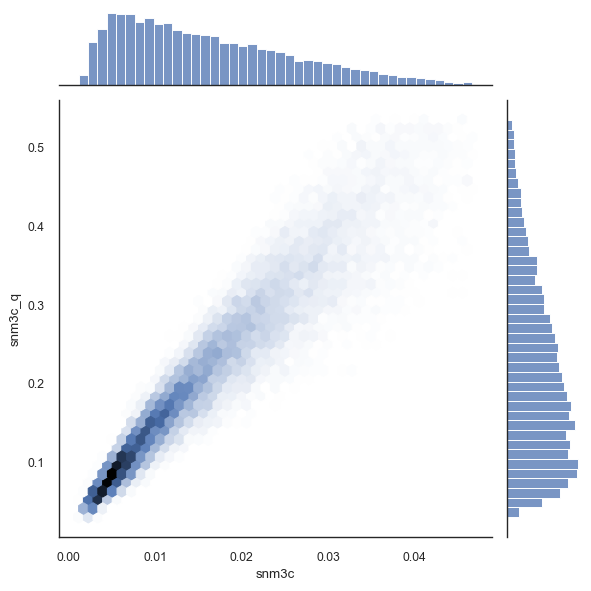

In [13]:
qlim = 0.9

mask_h1 = (~matrix_df['mask.diffM']) & (matrix_df['i.hmlg'] == 1) & (matrix_df['j.hmlg'] == 1) & (matrix_df.snm3c.notnull())
# mask_h1 = (~matrix_df['mask.diffM'])
# mask_h1 = matrix_df.index
mask = mask_h1 & (matrix_df.snm3c <= matrix_df.loc[mask_h1].snm3c.quantile(qlim)) & (matrix_df.snm3c_q <= matrix_df.loc[mask_h1].snm3c_q.quantile(qlim))
sns.jointplot(matrix_df[mask], x='snm3c', y='snm3c_q', kind='hex')
plt.show()

## Compare

In [11]:
%run fit_pseudocount_func.py load

In [13]:
%run plot_pseudocount_func.py

In [193]:
results_df = None
results = []
results_file = f"pseudocounts_vs_snm3c.{'raw' if '.raw.' in mcool_file.lower() else 'q'}.tsv"
if os.path.exists(results_file):
    results_df = pd.read_csv(results_file, sep='\t')
    results = results_df.to_dict(orient='records')
print(f"{len(results_df)} entries:")
display(results_df.head())

49 entries:


,func,func_kwargs,mean,med,genomic_dis_min,genomic_dis_max
0,logistic,"k=-53.36, v=15.72, x0=0.2792, q=1",0.776125,0.840757,0.0,inf
1,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.766203,0.606660,1.0,3.0
2,logistic,"k=-14.71, v=1, x0=0.4515, q=1",0.765700,0.555472,1.0,3.0
3,power,alpha=-1.35,0.744055,0.748455,NaN,NaN
4,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.679309,0.476740,9.0,9.0


### With/without inter-hmlg data

#### Comparisons

In [732]:
result_idx = 0

tmp = plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df.loc[result_idx].to_frame().T.reset_index(drop=True), plot=False)[0]
for x in ('mean', 'med'):
    prev = results_df.loc[result_idx, x]
    print(f"{x:<4}... prev={prev:<4.4g}     current={tmp[x]:<4.4g}     adding inter-hmlg ↑R by {(tmp[x] - prev)/prev * 100:.4g}%")

mean... prev=0.7951     current=0.7954     adding inter-hmlg ↑R by 0.03009%
med ... prev=0.6686     current=0.6665     adding inter-hmlg ↑R by -0.3209%


In [739]:
result_idx = 50

tmp = plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df.loc[result_idx].to_frame().T.reset_index(drop=True), plot=False)[0]
for x in ('mean', 'med'):
    prev = results_df.loc[result_idx, x]
    print(f"{x:<4}... prev={prev:<4.4g}     current={tmp[x]:<4.4g}     adding inter-hmlg ↑R by {(tmp[x] - prev)/prev * 100:.4g}%")

mean... prev=0.7921     current=0.793     adding inter-hmlg ↑R by 0.1111%
med ... prev=0.8351     current=0.8321     adding inter-hmlg ↑R by -0.3673%


In [758]:
result_idx = results_df.loc[results_df.func == 'power'].index[0]

tmp = plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df.loc[result_idx].to_frame().T.reset_index(drop=True), plot=False)[0]
for x in ('mean', 'med'):
    prev = results_df.loc[result_idx, x]
    print(f"{x:<4}... prev={prev:<4.4g}     current={tmp[x]:<4.4g}     adding inter-hmlg ↑R by {(tmp[x] - prev)/prev * 100:.4g}%")

mean... prev=0.7479     current=0.752     adding inter-hmlg ↑R by 0.5507%
med ... prev=0.7597     current=0.7625     adding inter-hmlg ↑R by 0.3647%


In [759]:
result_idx = results_df.loc[results_df.func == 'thresholded'].index[0]

tmp = plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df.loc[result_idx].to_frame().T.reset_index(drop=True), plot=False)[0]
for x in ('mean', 'med'):
    prev = results_df.loc[result_idx, x]
    print(f"{x:<4}... prev={prev:<4.4g}     current={tmp[x]:<4.4g}     adding inter-hmlg ↑R by {(tmp[x] - prev)/prev * 100:.4g}%")

mean... prev=0.739     current=0.7376     adding inter-hmlg ↑R by -0.1875%
med ... prev=nan      current=nan      adding inter-hmlg ↑R by nan%


#### Re-generate with inter-hmlg data

In [794]:
func = 'logistic'

filtered_for_func = results_df_intraM[(results_df_intraM.func == func)]
# display(filtered_for_func.loc[filtered_for_func.index.values[40:]])

# filtered_for_func.index.values[:40]

i = 40
# results_df_intraM.loc[i, 'func_kwargs']

In [789]:
# results_df_intraM = results_df.copy()

func = 'logistic'

filtered_for_func = results_df_intraM[(results_df_intraM.func == func)]
display(filtered_for_func)

for i in filtered_for_func.index.values[40:]:
    
    print(f'{i}')
    results.append(plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df_intraM.loc[i].to_frame().T.reset_index(drop=True), plot=False)[0])
    results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
    results_df.to_csv('pseudocounts_vs_snm3c.tsv', sep='\t', index=False)
    # display(results_df.head(1))

print('\nFINAL:')
display(results_df.head())

,func,func_kwargs,mean,med
0,logistic,"k=-25, v=2, x0=0.4",0.795123,0.668640
1,logistic,"k=-35, v=3, x0=0.4",0.795006,0.697630
2,logistic,"k=-45, v=4, x0=0.4",0.794885,0.711934
3,logistic,"k=-50, v=4, x0=0.4",0.794845,0.668559
4,logistic,"k=-40, v=3, x0=0.4",0.794814,0.639160
...,...,...,...,...
153,logistic,"k=-25, v=2, x0=1",0.730676,0.831061
155,logistic,"k=-2, v=1, x0=0",0.727009,0.755504
159,logistic,"k=-2.5, v=2, x0=0",0.698433,0.704401
160,logistic,"k=-15, v=1, x0=0",0.688459,0.580504


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39

FINAL:


,func,func_kwargs,mean,med
0,logistic,"k=-25, v=2, x0=0.4",0.795362,0.666494
1,logistic,"k=-35, v=3, x0=0.4",0.795301,0.695312
2,logistic,"k=-20, v=2, x0=0.4",0.795257,0.750934
3,logistic,"k=-45, v=4, x0=0.4",0.795207,0.709532
4,logistic,"k=-30, v=3, x0=0.4",0.795144,0.750747


### Comparing transfer func / params

In [39]:
%run plot_pseudocount_func.py

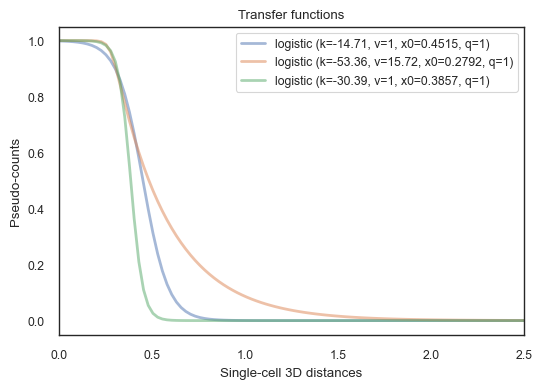

In [44]:
funcs_and_kwargs = []

k, x0 = np.array([-14.71402465, 0.45154928]); v = q = 1 # best from INITIAL inference: pearson.weight0, seed=0
funcs_and_kwargs.append([logistic, dict(k=k, v=v, x0=x0, q=q)])

k=-53.3559;  x0=0.279179;  v=15.7212    # obj=-0.75257981 ... pearson.weight-2.infer_nu, seed=1
funcs_and_kwargs.append([logistic, dict(k=k, v=v, x0=x0, q=q)])

k, x0 = [-30.394863085563795, 0.385748734297981]; v = q = 1  # obj=0.055002832 ... rmse.weight-1, seed=0
funcs_and_kwargs.append([logistic, dict(k=k, v=v, x0=x0, q=q)])

plot_transfer_func_multiple(sc_dis, funcs_and_kwargs, figsize=(6, 4), dpi=None, linewidth=2, xmax=2.5)

### Lower outliers

In [158]:
%run plot_pseudocount_func.py

<Figure size 640x440 with 0 Axes>

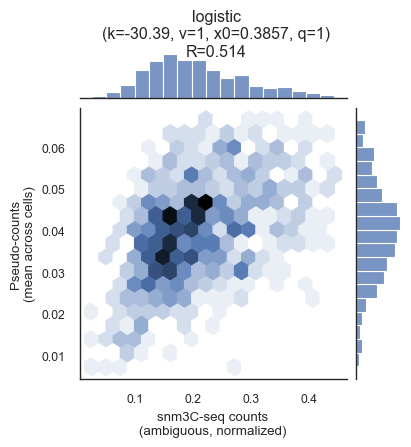

In [151]:
k, x0 = [-30.394863085563795, 0.385748734297981]; v = q = 1  # obj=0.055002832 ... rmse.weight-1, seed=0

genomic_dis_min = genomic_dis_max = 1

pearson_r, (_, matrix_df_ambig) = res = assess_pseudocounts(
    matrix_df[(matrix_df.genomic_dis_ambig >= genomic_dis_min) & (matrix_df.genomic_dis_ambig <= genomic_dis_max)],
    sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, v=v, x0=x0, q=q), plot=True)
matrix_df_ambig.drop('pc_med', axis=1, inplace=True)

<Figure size 640x440 with 0 Axes>

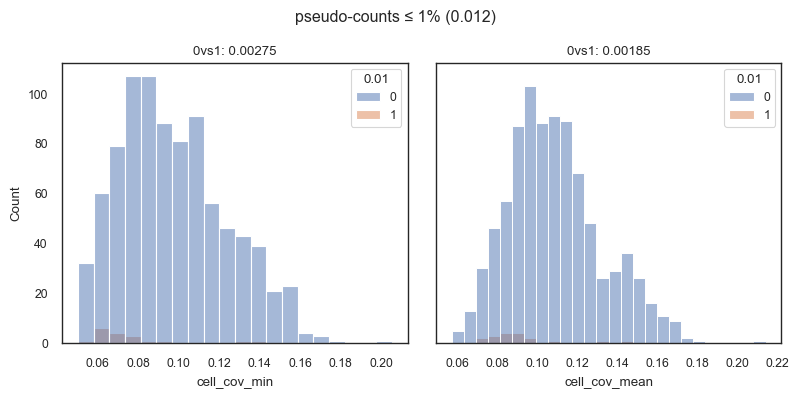

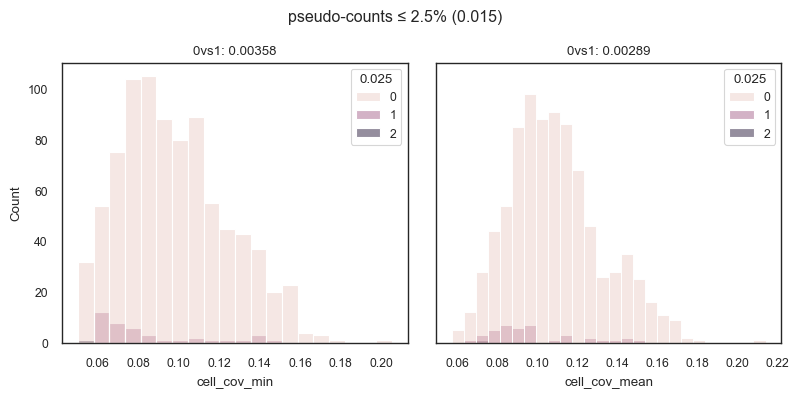

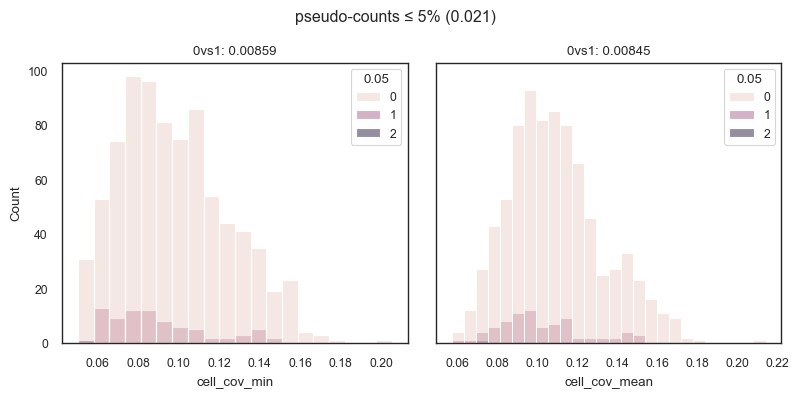

In [159]:
lengths_df_outliers = None

for perc_cutoff in [0.01, 0.025, 0.05]:
    outliers, lengths_df_outliers = assess_lower_outliers(matrix_df_ambig, lengths_df=lengths_df, perc_cutoff=perc_cutoff, lengths_df_outliers=lengths_df_outliers, verbose=False)

#### Examining specific genomic distance bins


GENOMIC DIS: s=1       


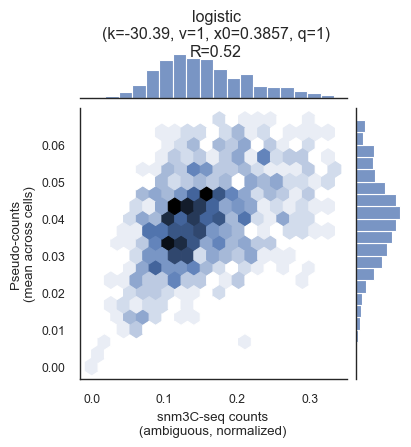


GENOMIC DIS: s=2       


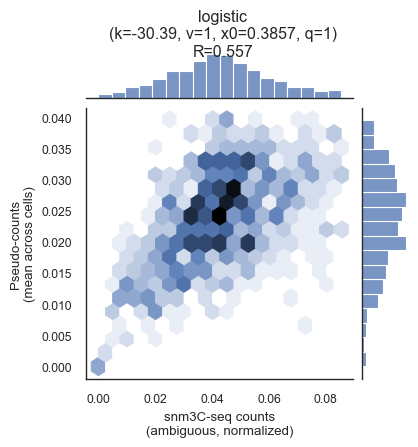


GENOMIC DIS: s=3       


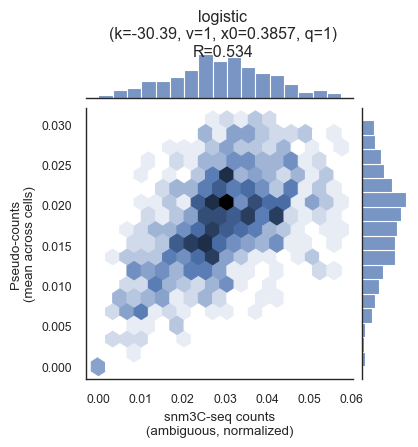


GENOMIC DIS: s=4       


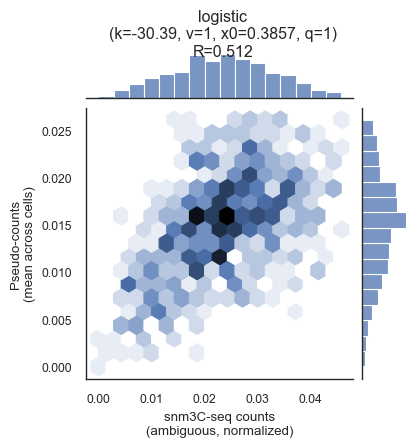

,func,func_kwargs,mean,med,genomic_dis_min,genomic_dis_max
33,logistic,"k=-30.39, v=1, x0=0.3857, q=1",0.557037,0.225836,2.0,2.0
37,logistic,"k=-30.39, v=1, x0=0.3857, q=1",0.534307,0.085179,3.0,3.0
45,logistic,"k=-30.39, v=1, x0=0.3857, q=1",0.520287,0.163777,1.0,1.0
47,logistic,"k=-30.39, v=1, x0=0.3857, q=1",0.511662,0.112294,4.0,4.0


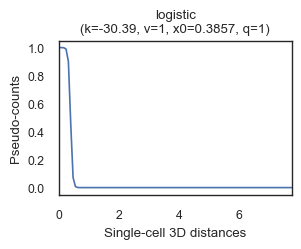

In [189]:
# RMSE, WEIGHT = 1/s
# [-30.394863085563795, 0.385748734297981]  # obj=0.055002832, seed=0, pgtol=1e-10

# RMSE, WITHOUT WEIGHTS
# k, d0
# [-25.52136772017525, 0.39707902525364497]  # obj=0.023229902, seed=0, pgtol=1e-10
# [-24.414438595193076, 0.39433848292756574] # obj=0.023230165, seed=1, pgtol=1e-5
# k, d0, nu
# [-11.78939201507849,  0.8051549003099034,  0.01]              # obj=0.023211055, seed=0, pgtol=1e-10
# [-24.413958929184393, 0.425210222962091, 0.6826513696104046]  # obj=0.023226203, seed=1, pgtol=1e-5


# k, x0 = np.array([-14.71402465, 0.45154928]); v = q = 1 # best from INITIAL inference: pearson.weight0, seed=0
# k=-13; v=1; x0=0.4; q=0.6  # best from MANUAL assessment
# k=-7.08407;  x0=0.807475;  v=0.0358141;   q=1
# k, x0 = [-25.52136772017525, 0.39707902525364497]; v = q = 1  # obj=-0.82056164 ... pearson.weight-1, seed=0
k, x0 = [-30.394863085563795, 0.385748734297981]; v = q = 1  # obj=0.055002832 ... rmse.weight-1, seed=0

# k=-53.3559;  x0=0.279179;  v=15.7212    # obj=-0.75257981 ... pearson.weight-2.infer_nu, seed=1


plot = True

# ====== BINS PER GENOMIC DIS
bins_per_genomic_dis = matrix_df.genomic_dis_ambig.value_counts()
snm3c_per_genomic_dis = matrix_df[matrix_df.genomic_dis.notnull()].groupby('genomic_dis').snm3c.mean()

# ====== EVALUATE
genomic_dis_list = [1, 2, 3, 4]
# genomic_dis_list = np.arange(5, bins_per_genomic_dis[bins_per_genomic_dis >= 2000].index.max())
# genomic_dis_list = [(1, 3), (10, np.inf)]
# genomic_dis_list = [(0, np.inf),]
for genomic_dis in genomic_dis_list:
    if isinstance(genomic_dis, (int, float)):
        genomic_dis_min = genomic_dis_max = genomic_dis
        desc=f's={genomic_dis}'.ljust(10)
    else:
        genomic_dis_min, genomic_dis_max = genomic_dis
        desc=f'{genomic_dis_min}≤s≤{genomic_dis_max}'.ljust(10)
    if plot:
        print(f"\nGENOMIC DIS: {desc}")
    res = assess_pseudocounts(
        matrix_df[(matrix_df.genomic_dis_ambig >= genomic_dis_min) & (matrix_df.genomic_dis_ambig <= genomic_dis_max)],
        sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, v=v, x0=x0, q=q), plot=plot)[0]
    if not plot:
        print(f"GENOMIC DIS: {desc}  R={res['mean']:.3g}")
    res['genomic_dis_min'] = genomic_dis_min
    res['genomic_dis_max'] = genomic_dis_max
    results.append(res)
    results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
    results_df.to_csv('pseudocounts_vs_snm3c.tsv', sep='\t', index=False)

print()
results_df_func_single = results_df[(results_df.func == res['func']) & (results_df.func_kwargs == res['func_kwargs']) & (
    results_df.genomic_dis_min == results_df.genomic_dis_max)]
results_df_func_range = results_df[(results_df.func == res['func']) & (results_df.func_kwargs == res['func_kwargs']) & (
    results_df.genomic_dis_min != results_df.genomic_dis_max)]
if len(results_df_func_single):
    display(results_df_func_single.head())
if len(results_df_func_range):
    display(results_df_func_range.head())


# # ====== TRANSFER FUNC
plot_transfer_func(sc_dis=sc_dis, func=logistic, func_kwargs=dict(k=k, v=v, x0=x0, q=q))

In [184]:
results_df[(results_df.func == res['func']) & (results_df.genomic_dis_min <= 4) & (
    results_df.genomic_dis_min == results_df.genomic_dis_max)].sort_values(['genomic_dis_min', 'mean'], ascending=[True, False])

,func,func_kwargs,mean,med,genomic_dis_min,genomic_dis_max
36,logistic,"k=-53.36, v=15.72, x0=0.2792, q=1",0.538999,0.471279,1.0,1.0
38,logistic,"k=-12.04, v=1, x0=0.4764, q=1",0.533887,0.421136,1.0,1.0
39,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.532764,0.406788,1.0,1.0
40,logistic,"k=-14.71, v=1, x0=0.4515, q=1",0.532633,0.383811,1.0,1.0
43,logistic,"k=-25.52, v=1, x0=0.3971, q=1",0.524435,0.221555,1.0,1.0
44,logistic,"k=-30.39, v=1, x0=0.3857, q=1",0.520287,0.163777,1.0,1.0
45,logistic,"k=-7.084, v=0.03581, x0=0.8075, q=1",0.517344,0.030232,1.0,1.0
8,logistic,"k=-53.36, v=15.72, x0=0.2792, q=1",0.632983,0.554040,2.0,2.0
14,logistic,"k=-12.04, v=1, x0=0.4764, q=1",0.615183,0.454234,2.0,2.0
18,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.605258,0.439104,2.0,2.0


##### Average 3D distance per genomic distance

In [182]:
def aggregate_3d_dis_per_s(df):
    res = {}
    for q in [0.1, 0.5, 0.9]:
        res[f"{q * 100:g}%"] = np.nanquantile(df.values, q)
    return pd.Series(res)

gb_idx = matrix_df.loc[sc_dis.index, 'genomic_dis'].astype(float).fillna(0).astype(int)
sc_dis_agg_by_s = sc_dis.groupby(gb_idx).apply(aggregate_3d_dis_per_s)
sc_dis_agg_by_s

,10%,50%,90%
genomic_dis,,,
0,2.056156,4.064038,6.454962
1,0.423736,0.925930,1.483939
2,0.518003,1.103284,1.891293
3,0.574071,1.217534,2.120598
4,0.612362,1.301689,2.280854
...,...,...,...
72,1.241744,2.444854,4.096053
73,1.253168,2.474395,4.180338
74,1.370950,2.561783,4.239522


##### Number of locus pairs per genomic distance

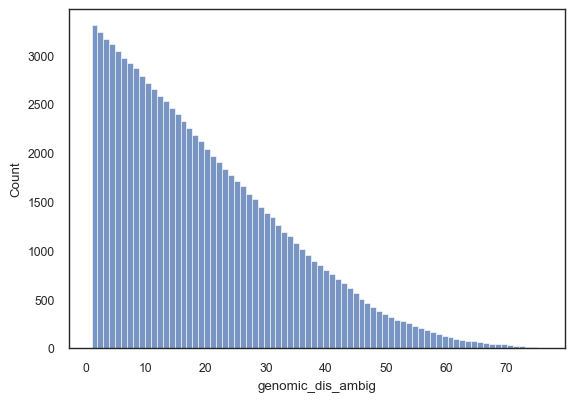

genomic_dis_ambig
1     3308
2     3244
3     3164
4     3112
5     3048
      ... 
72      20
73      16
74      12
75       8
76       4
Name: count, Length: 77, dtype: int64

In [49]:
bins_per_genomic_dis = matrix_df.genomic_dis_ambig.value_counts()

sns.histplot(
    matrix_df[matrix_df.genomic_dis_ambig.notnull() & (matrix_df.genomic_dis_ambig != 0)],
    x='genomic_dis_ambig', bins=matrix_df.genomic_dis_ambig.max())
plt.show()

bins_per_genomic_dis = matrix_df.genomic_dis_ambig.value_counts()
bins_per_genomic_dis

#### Comparing to best params from inference

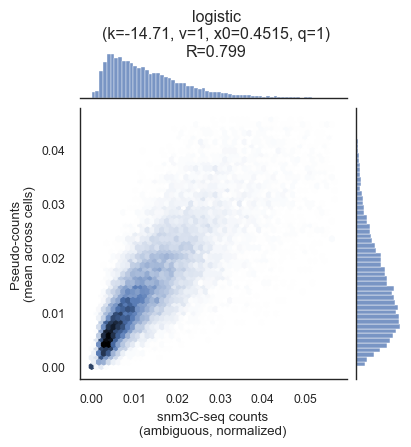

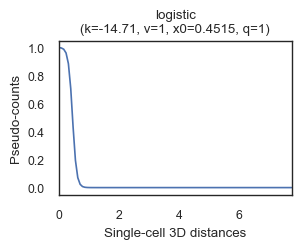

In [164]:
k, x0 = np.array([-14.71402465, 0.45154928])
v = q = 1

assess_pseudocounts(matrix_df, sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, v=v, x0=x0, q=q), plot=True)[0]

plot_transfer_func(sc_dis=sc_dis, func=logistic, func_kwargs=dict(k=k, v=v, x0=x0, q=q))

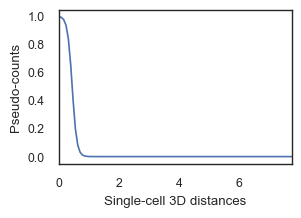

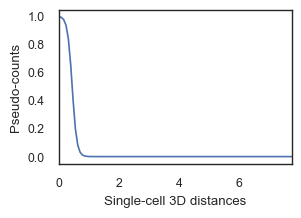

In [46]:
plot_transfer_func(sc_dis=sc_dis, func=logistic, func_kwargs=dict(k=k, v=v, x0=x0, q=q))
plot_best_transfer_func(results_df, sc_dis)

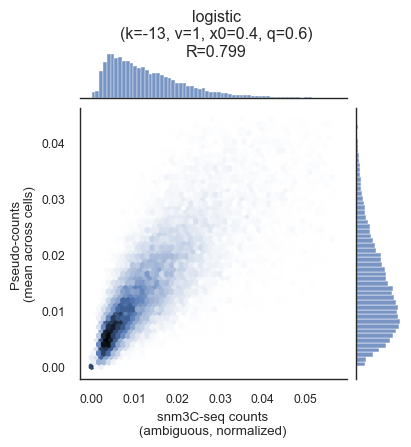

{'func': 'logistic',
 'func_kwargs': 'k=-13, v=1, x0=0.4, q=0.6',
 'mean': 0.7992016084888707,
 'med': 0.6570021242547587}

In [41]:
plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df)[0]

#### Manual

In [ ]:
display(results_df.head(1).rename({0: f"BEST"}))
print()

for v in [1]:
    for k in [round(-13 * v, 2)]:
        for x0 in [0.4]:
            for q in [0.6]:
                results.append(assess_pseudocounts(matrix_df, sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, v=v, x0=x0, q=q))[0])
    results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
    results_df.to_csv('pseudocounts_vs_snm3c.tsv', sep='\t', index=False)
    display(results_df[results_df.func_kwargs.str.contains(f'{k=},')].head(1))

results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
results_df.to_csv('pseudocounts_vs_snm3c.tsv', sep='\t', index=False)
print('\nFINAL:')
display(results_df.head())


print('\n...')
display(results_df[results_df.func_kwargs.str.contains('q=') | (results_df.func_kwargs == 'k=-25, v=2, x0=0.4')].head())


plot_best_transfer_func(results_df, sc_dis)
_ = plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df)

,func,func_kwargs,mean,med
BEST,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.795715,0.655148


### Logistic

### Threshold power func

In [539]:
# TODO Test this... with upper/lower cutoff, like for dist decay below !!!!

### Thresholded func

,func,func_kwargs,mean,med
THRESH: BEST,thresholded,cutoff=0.5,0.739005,NaN


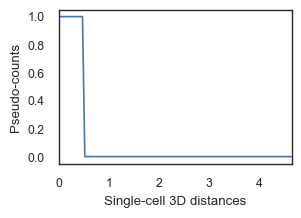

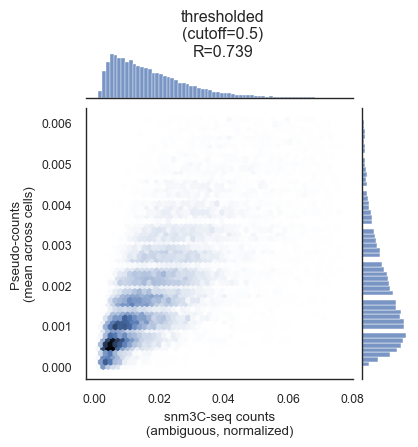

In [538]:
# results.append(assess_pseudocounts(matrix_df, sc_dis, transfer_func=thresholded, transfer_func_kwargs=dict(cutoff=0.5), plot=False)[0])
# results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
# results_df.to_csv('pseudocounts_vs_snm3c.tsv', sep='\t', index=False)

results_df_thr = results_df[results_df.func == 'thresholded'].reset_index(drop=True)
display(results_df_thr.head(1).rename({0: f"THRESH: BEST"}))
plot_best_transfer_func(results_df_thr, sc_dis=sc_dis)
plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df_thr)

### Power func

,func,func_kwargs,mean,med,genomic_dis_min,genomic_dis_max
POWER: BEST,power,alpha=-1.35,0.744055,0.748455,NaN,NaN


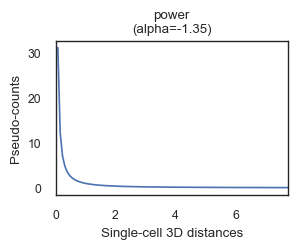

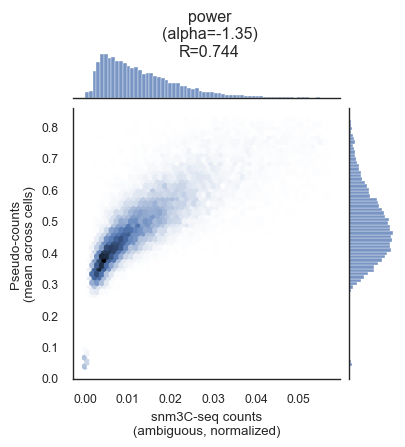

({'func': 'power',
  'func_kwargs': 'alpha=-1.35',
  'mean': 0.7440545849947914,
  'med': 0.7484553863442547},
 (              i.idx  j.idx  i.idx_chrom  j.idx_chrom  chrom  i.idx_ambig  \
  (0, 1)            0      1            0            1   chr1            0   
  (0, 2)            0      2            0            2   chr1            0   
  (0, 3)            0      3            0            3   chr1            0   
  (0, 4)            0      4            0            4   chr1            0   
  (0, 5)            0      5            0            5   chr1            0   
  ...             ...    ...          ...          ...    ...          ...   
  (1921, 1923)   1921   1923           19           21  chr19          958   
  (1921, 1924)   1921   1924           19           22  chr19          958   
  (1922, 1923)   1922   1923           20           21  chr19          959   
  (1922, 1924)   1922   1924           20           22  chr19          959   
  (1923, 1924)   1923   1924   

In [183]:
results.append(assess_pseudocounts(matrix_df, sc_dis, transfer_func=power, transfer_func_kwargs=dict(alpha=-1.35), plot=False)[0])
results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
results_df.to_csv('pseudocounts_vs_snm3c.tsv', sep='\t', index=False)

# results_df.loc[results_df.func_kwargs.str.contains('alpha'), 'func'] = 'power'

results_df_power = results_df[results_df.func == 'power'].reset_index(drop=True)
display(results_df_power.head(1).rename({0: f"POWER: BEST"}))
plot_best_transfer_func(results_df_power, sc_dis=sc_dis)
plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df_power)

## Fxn - compare

##### Weighted pearsons test

In [44]:
jnp = np

# def weighted_mean(x, weights):
#     # return jnp.sum(x * weights) / jnp.sum(weights)
#     return jnp.average(x, weights=weights)

def weighted_cov(x, y, weights=1):
    if isinstance(weights, (int, float)):
        weights = np.full_like(x, weights)
    x_weighted = jnp.average(x, weights=weights)
    y_weighted = jnp.average(y, weights=weights)
    # return jnp.sum(weights * (x - x_weighted) * (y - y_weighted)) / jnp.sum(weights)
    return np.average((x - x_weighted) * (y - y_weighted), weights=weights)


def weighted_pearsons_corr(x, y, weights=1):
    if isinstance(weights, (int, float)):
        weights = np.full_like(x, weights)
    return weighted_cov(x, y, weights) / jnp.sqrt(
        weighted_cov(x, x, weights) * weighted_cov(y, y, weights))

In [45]:
rng = np.random.default_rng(seed=42)
xarr = rng.random(5)
yarr = rng.random(5)

print(np.corrcoef(xarr, yarr)[0, 1])
print(weighted_pearsons_corr(xarr, yarr, weights=1))

0.2901466209451473
0.29014662094514737


## Looking at inter-hmlg data (intra-chrom only)

### Plot inter-hmlg data

INTER-HMLG DATA - SINGLE-CELL:

NaNs are 96.8% of the data

5,360,238 non-NaN values, summary:
mean     4.18
std      1.71
min      0.03
25%      2.94
50%      4.06
75%      5.29
max     13.14


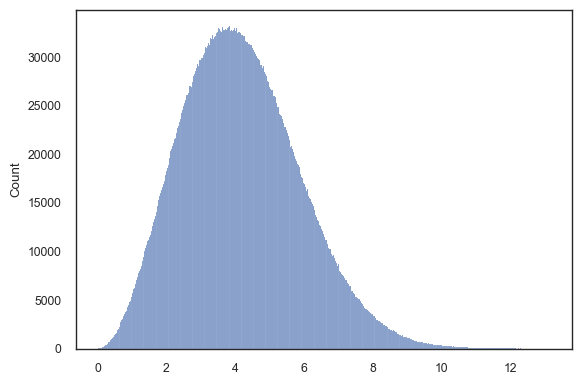



INTER-HMLG DATA - MEAN ACROSS CELLS:

NaNs are 0% of the data

45,598 non-NaN values, summary:
mean    4.17
std     0.36
min     2.61
25%     3.97
50%     4.21
75%     4.43
max     5.42


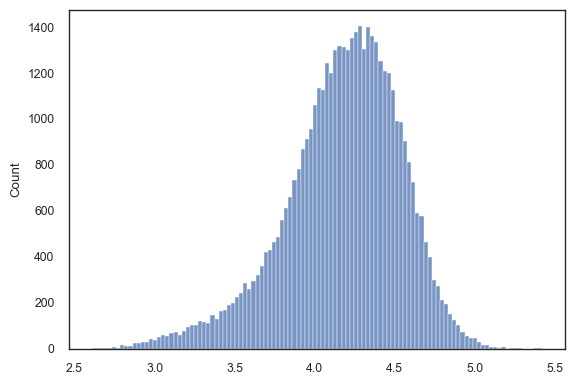

In [710]:
tmp = sc_dis.loc[matrix_df[matrix_df['mask.diffM']].index].values
print(f"INTER-HMLG DATA - SINGLE-CELL:\n\nNaNs are {np.isnan(tmp).sum() / tmp.size * 100:.3g}% of the data")
tmp = tmp[~np.isnan(tmp)]
print(f'\n{tmp.size:,} non-NaN values, summary:\n' + pd.Series(tmp).describe().round(2).drop('count').to_string())
sns.histplot(tmp)
plt.show()

tmp = sc_dis.loc[matrix_df[matrix_df['mask.diffM']].index].mean(axis=1).values
print(f"\n\nINTER-HMLG DATA - MEAN ACROSS CELLS:\n\nNaNs are {np.isnan(tmp).sum() / tmp.size * 100:.3g}% of the data")
tmp = tmp[~np.isnan(tmp)]
print(f'\n{tmp.size:,} non-NaN values, summary:\n' + pd.Series(tmp).describe().round(2).drop('count').to_string())
sns.histplot(tmp)
plt.show()

tmp = None

### Test: aggregate `matrix_df` to ambiguous, when using inter-hmlg data

In [670]:
# grp_cols = ['i.idx_ambig', 'j.idx_ambig', 'chrom', 'i.idx_chrom', 'j.idx_chrom',
#             'genomic_dis', 'mask.nghbr', 'i.idx_clr', 'j.idx_clr']
# excluded_cols = ['i.idx', 'j.idx', 'i.hmlg', 'j.hmlg', 'mask.diffM']


# # old version
# tmp = matrix_df[matrix_df.columns[~matrix_df.columns.isin(
#     excluded_cols)]].groupby(grp_cols).apply(lambda x: len(x), include_groups=False)
# print(tmp.value_counts())
# tmp = None

1    22744
3    21855
Name: count, dtype: int64


In [675]:
grp_cols = ['i.idx_ambig', 'j.idx_ambig', 'chrom', 'i.idx_chrom', 'j.idx_chrom',
            'i.idx_clr', 'j.idx_clr']
excluded_cols = ['i.idx', 'j.idx', 'i.hmlg', 'j.hmlg', 'mask.diffM', 'mask.nghbr', 'genomic_dis']
matrix_df_ambig = matrix_df.copy()
mask_swap = matrix_df['i.idx_ambig'] > matrix_df['j.idx_ambig']
if mask_swap.any():  # Ambig index pair should fall in upper triangular
    for col in ('idx_ambig', 'idx_chrom', 'idx_clr'):
        matrix_df_ambig.loc[mask_swap, f'i.{col}'] = matrix_df.loc[mask_swap, f'j.{col}']
        matrix_df_ambig.loc[mask_swap, f'j.{col}'] = matrix_df.loc[mask_swap, f'i.{col}']
matrix_df_ambig = matrix_df_ambig[  # Remove diagonal
    matrix_df_ambig['i.idx_ambig'] != matrix_df_ambig['j.idx_ambig']].drop(excluded_cols, axis=1)
print(len(matrix_df_ambig), len(matrix_df))

tmp = matrix_df_ambig.groupby(grp_cols).apply(lambda x: len(x), include_groups=False)
print(tmp.value_counts())

tmp = tmp.to_frame().reset_index(level=np.arange(len(grp_cols)).tolist()).rename({0: 'n'}, axis=1)
print((tmp['i.idx_ambig'] > tmp['j.idx_ambig']).any())

tmp = None
matrix_df_ambig = None

89396 90296
4    21855
Name: count, dtype: int64
False


# Infer pseudocounts transfer func params

## Load

In [ ]:
%run fit_pseudocount_func.py load

In [ ]:
import pandas as pd
import glob
import os
import ast
import numpy as np
import re

from fit_pseudocount_func import prep_data_for_inference
# from fit_pseudocount_func import load, prep_data_for_inference, ambiguate_matrix_df_for_inference, InferArgs, _setup_jax

dir_matrix2d = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/cluster.LINK/astro/compare_to_1cell/matrix2d'
# mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool'
mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/selected/Astro-TE_NN.Raw.100K.mcool'
resolution = int(1000 * 1000 * 2.5) # 2.5 Mb (2.5e6 bp)
# resolution = int(1000 * 500) # 500 kb (5e5 bp)

data_outdir="nobackup"
name = re.sub(r'(^|.*/)cluster(?:\.LINK){0,1}/([^/]+)(/.*|$)', r'\2', os.path.dirname(dir_matrix2d))
snm3c_type = f"{'raw' if '.raw.' in mcool_file.lower() else 'q'}_snm3c"
name = f"{name}.{snm3c_type}"

data = prep_data_for_inference(dir_matrix2d, mcool_file=mcool_file, resolution=resolution, data_outdir=data_outdir, name=name, verbose=True)
assert isinstance(data.snm3c, np.ndarray) and data.snm3c.size
assert isinstance(data.dis, np.ndarray) and data.dis.size

In [25]:
mcool_file = '.raw.'
snm3c_type = f"{'raw' if '.raw.' in mcool_file.lower() else 'q'}_snm3c"
snm3c_type

'raw_snm3c'

## Infer - qsub

In [195]:
%%bash

# qlogin -l mfree=60G,cpuid_level=13

cd ~/noble_lab/repos/Chromatin_Analysis_MOp/jupyter
dir_matrix2d='/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/cluster.LINK/astro/compare_to_1cell/matrix2d'
# mcool_file='/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool'
mcool_file='/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/selected/Astro-TE_NN.Raw.100K.mcool'
resolution_mb=2.5
# export JAX_CAPTURED_CONSTANTS_WARN_BYTES=-1
sge_outdir='nobackup/sge_out'
if [[ "$mcool_file" == *'Raw'* ]]; then
    sge_outdir="$sge_outdir/snm3c_raw"
else
    sge_outdir="$sge_outdir/snm3c_q"
fi
mkdir -p "$sge_outdir"

echo "$sge_outdir"

run_inference() {
    use_sge=$1
    seed=$2
    obj_type=$3
    weight=$4
    if [[ "$5" == 'false' ]]; then
        args=''
    else
        args=$5
    fi
    factr=$6
    pgtol=$7

    echo -e "====== seed=$seed, obj_type=$obj_type, weight=$weight, args='$args', factr=$factr, pgtol=$pgtol"

    args_str=$( echo "$args" | sed -r 's/(^ *){0,1}--infer_(nu|q)( *$){0,1}/\2/g;s/q nu/nu q/;s/ /_/;s/^(.)/.infer_\1/' )
    jobname="FIT.$obj_type.weight$weight$args_str.s$seed"

    if $use_sge; then
        qsub -P noblelab -cwd -V -l mfree=60G -o "$sge_outdir" -j "yes" -N "$jobname" -R y -b y \
        python fit_pseudocount_func.py "$dir_matrix2d" --mcool_file "$mcool_file" --resolution_mb "$resolution_mb" \
        --outdir 'nobackup' --factr $factr --pgtol $pgtol --obj_type $obj_type --weights_exponent $weight $args \
        --seed $seed
    else
        python fit_pseudocount_func.py "$dir_matrix2d" --mcool_file "$mcool_file" --resolution_mb "$resolution_mb" \
        --outdir 'nobackup' --factr $factr --pgtol $pgtol --obj_type $obj_type --weights_exponent $weight $args \
        --seed $seed
    fi
}


# ====== OPTIONS
# obj_type="rmse"; factr=10; pgtol=1e-10
obj_type="pearson"; factr=10; pgtol=1e-10 #factr=1e7; pgtol=1e-5

weight=0
# weight='-2'

# args=false
args='--infer_nu'

seeds=$(seq 0 1)

# use_sge=true
# for seed in $seeds; do
#     run_inference $use_sge $seed $obj_type $weight $args $factr $pgtol
# done

nobackup/sge_out/snm3c_raw


In [155]:
%%bash

cd ~/noble_lab/repos/Chromatin_Analysis_MOp/jupyter/nobackup/sge_out

gcq stat x

prev_desc=''
for each in $(find . -maxdepth 1 -type f | sort); do
    desc=$( echo $each | sed 's/.*FIT\.//;s/\.s[0-9][0-9]*\.o[0-9][0-9]*$//' )
    seed=$( echo $each | sed -r 's/.+\.s([0-9][0-9]*)\.o[0-9][0-9]*$/\1/' )
    if [[ "$prev_desc" != "$desc" ]]; then
        echo -e "\n====== "$( echo "$desc" | sed 's/\./, /g' )
    fi
    final='...'
    if grep -q 'results   scaling_factor' "$each"; then
        final='✓✓✓'
    fi
    last_iter=$(grep 'd₀.*obj=' "$each" | tail -n 1 | sed -r $'s/ +\.\.\. /#/;s/   */;  /g;s/#/# /')
    obj=$( echo "$last_iter" | sed -r 's/^.+# obj=//' )
    params=$( echo "$last_iter" | sed -r 's/# obj=.+$//;s/d₀/d0/;s/𝜈/nu/' )
    params=$( printf "%-40s" "$params" )
    echo -e "$final\t$params # obj=$obj ... $desc, seed=$seed"

    prev_desc="$desc"
done

20072723	r  07/17...01:05p JUPYTER.cpuid_level_13,mfree_30G 0
running: 1

====== pearson, weight-1, infer_nu
✓✓✓	k=-6.5879;  d0=0.763108;  nu=0.177565    # obj=-0.82059935 ... pearson.weight-1.infer_nu, seed=0
✓✓✓	k=-6.5879;  d0=0.763107;  nu=0.177565    # obj=-0.82059935 ... pearson.weight-1.infer_nu, seed=1

====== pearson, weight-1
✓✓✓	k=-12.0354;  d0=0.476371                 # obj=-0.82056164 ... pearson.weight-1, seed=0
✓✓✓	k=-12.0354;  d0=0.476371                 # obj=-0.82056164 ... pearson.weight-1, seed=1

====== pearson, weight-2, infer_nu
✓✓✓	k=-62.8401;  d0=0.267773;  nu=19.0443    # obj=-0.75257239 ... pearson.weight-2.infer_nu, seed=0
✓✓✓	k=-53.3559;  d0=0.279179;  nu=15.7212    # obj=-0.75257981 ... pearson.weight-2.infer_nu, seed=1

====== pearson, weight-2
✓✓✓	k=-4.1788;  d0=0.234876                  # obj=-0.7516745 ... pearson.weight-2, seed=0
✓✓✓	k=-4.1788;  d0=0.234876                  # obj=-0.7516745 ... pearson.weight-2, seed=1


In [ ]:
k=-12.04, v=1, x0=0.4764, q=1

# ====== pearson, weight-2, infer_nu, bound5
# ✓✓✓	k=-18.0954;	d₀=0.285502;	𝜈=5;	# obj=-0.75236783  pearson.weight-2.infer_nu-max5, seed=0
# ✓✓✓	k=-18.0954;	d₀=0.285502;	𝜈=5;	# obj=-0.75236783  pearson.weight-2.infer_nu-max5, seed=1

# ====== pearson, weight-2, infer_nu, bound50
# ✓✓✓	k=-50;	d₀=0.283085;	𝜈=14.4238;	# obj=-0.75257686  pearson.weight-2.infer_nu, seed=0
# ✓✓✓	k=-50;	d₀=0.283085;	𝜈=14.4238;	# obj=-0.75257686  pearson.weight-2.infer_nu, seed=1

# RMSE, WEIGHT = 1/s
# [-30.394863085563795, 0.385748734297981]  # obj=0.055002832, seed=0, pgtol=1e-10

# RMSE, WITHOUT WEIGHTS
# k, d0
# [-25.52136772017525, 0.39707902525364497]  # obj=0.023229902, seed=0, pgtol=1e-10
# [-24.414438595193076, 0.39433848292756574] # obj=0.023230165, seed=1, pgtol=1e-5
# k, d0, nu
# [-11.78939201507849,  0.8051549003099034,  0.01]              # obj=0.023211055, seed=0, pgtol=1e-10
# [-24.413958929184393, 0.425210222962091, 0.6826513696104046]  # obj=0.023226203, seed=1, pgtol=1e-5

## Infer

### Infer with 'Pearson'

In [15]:
_setup_jax(traceback=False, debug_nan_inf=False)


# init = None; seed = 0; intramol_only = False; infer_nu=True; infer_q=True
# # k=-17.91  d₀=0.4822  𝜈=0.5953  q=0.8201  ... R=0.79947835 ** using k = alpha * nu !!
# init = np.array([-17.91001729, 0.48224009, 0.59530008, 0.82009542])  # R=0.799478346764533

# init = None; seed = 1; intramol_only = False; infer_nu=True; infer_q=True
# # k=-24.83  d₀=0.002421  𝜈=4.582   q=47.43   ... R=0.79241673 ** using k = alpha !!

# init = None; seed = 1; intramol_only = True; infer_nu=True; infer_q=True
# # k=-24.41  d₀=0.9505  𝜈=7.208   q=47.43   ... R=0.72496335
# # k=-24.51  d₀=0       𝜈=6.818   q=47.43   ... R=0.77727566
# # k=-24.74  d₀=0       𝜈=6.024   q=47.43   ... R=0.7826702

# init = None; seed = 1; intramol_only = True; infer_nu=True; infer_q=False
# # k=-24.41  d₀=0.9505  𝜈=7.208   q=1       ... R=0.70416431
# # k=-24.96  d₀=0.03108  𝜈=4.424   q=1       ... R=0.78849082
# # k=-25.32  d₀=1       𝜈=2.22e-14  q=1       ... R=-1  
# init = None; seed = 1; intramol_only = False; infer_nu=True; infer_q=False
# # # k=-24.41  d₀=0.9505  𝜈=7.208   q=1       ... R=0.0.71330448


# init = None; seed = 1; intramol_only = False; infer_nu=False; infer_q=False
# # k=-24.41  d₀=0.9505  𝜈=1       q=1       ... R=0.75246586
# # k=-14.71  d₀=0.4515  𝜈=1       q=1       ... R=0.79936276
# # init = array([-14.71402465,   0.45154928])

# init = None; seed = 0; intramol_only = False; infer_nu=False; infer_q=False
# # k=-18.15  d₀=0.2698  𝜈=1       q=1       ... R=0.77376346
# # k=-14.71  d₀=0.4515  𝜈=1       q=1       ... R=0.79936276
# # array([-14.71465111,   0.4515491 ])} # **** using this

# init = None; seed = 0; intramol_only = False; infer_nu=False; infer_q=False
# # k=-18.22  d₀=0.2698  𝜈=0.5205  q=1       ... R=0.7352575
# # k=-18.17  d₀=0.4805  𝜈=0.9109  q=1       ... R=0.79918057
# # array([-18.16812632,   0.48048507,   0.91086788])


d = estimate_logistic_param(
    data=data, intramol_only=intramol_only, infer_nu=infer_nu, infer_q=infer_q, init=init, bounds=None, seed=seed,
    max_iter=1e20, jitted=True, verbose=2)
d

α=-18.22  d₀=0.2698  𝜈=0.5205  q=1       ... INIT
OPTIMIZING:
α=-18.22  d₀=0.2698  𝜈=0.5205  q=1       ... R=0.7352575
α=-18.22  d₀=0.2698  𝜈=0.5205  q=1       ... R=0.7352575
α=-18.21  d₀=0.9301  𝜈=0.6513  q=1       ... R=0.76010447
α=-18.21  d₀=0.8153  𝜈=0.636   q=1       ... R=0.7756828
α=-18.21  d₀=0       𝜈=0.5     q=1       ... R=0.3813647
α=-18.21  d₀=0.724   𝜈=0.6208  q=1       ... R=0.78637919
α=-18.21  d₀=0.2851  𝜈=0.5404  q=1       ... R=0.74699552
α=-18.21  d₀=0.5595  𝜈=0.5907  q=1       ... R=0.79842481
α=-18.21  d₀=0.4972  𝜈=0.5804  q=1       ... R=0.79855253
α=-18.21  d₀=0.5283  𝜈=0.5855  q=1       ... R=0.79893607
α=-18.21  d₀=0.5246  𝜈=0.586   q=1       ... R=0.79894165
α=-18.21  d₀=0.5245  𝜈=0.5871  q=1       ... R=0.79894262
α=-18.21  d₀=0.5242  𝜈=0.5913  q=1       ... R=0.79894644
α=-18.21  d₀=0.5229  𝜈=0.6083  q=1       ... R=0.79896072
α=-18.18  d₀=0.4891  𝜈=0.8986  q=1       ... R=0.79915958
α=-18.11  d₀=0.418   𝜈=1       q=1       ... R=0.79793948
α=-18.17  d₀=0

{'grad': array([-8.27157880e-05, -1.02252571e-03, -6.48439494e-04]),
 'task': 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH',
 'funcalls': 20,
 'nit': 11,
 'warnflag': 0,
 'converged': True,
 'obj': -0.7991805723661407,
 'params': array([-18.16812632,   0.48048507,   0.91086788])}

### Infer with 'MSE'

In [38]:
print(data.dis[data.dis != 0].min(), data.dis.max())

0.0084146057964652 13.143100730482354


In [46]:
%run fit_pseudocount_func.py load

In [ ]:
_setup_jax(traceback=False, debug_nan_inf=True); jitted=False
# _setup_jax(traceback=False, debug_nan_inf=False); jitted=True
factr=1e7; maxls=20; pgtol=1e-05

# # ======== MSE, not RMSE:
# init=None; seed=0; intramol_only=False; infer_nu=False; infer_q=False  # MSE, not RMSE
# # k=-18.22  d₀=0.2698 ... obj=0.000612209
# # k=-18.22  d₀=0.3035 ... obj=0.00054776111
# init=None; seed=1; intramol_only=False; infer_nu=False; infer_q=False  # MSE, not RMSE
# # k=-24.46  d₀=0.9505 ... INIT
# # k=-24.46  d₀=0.314  ... obj=0.00055311297

# # ======== RMSE:
# init=[-24.45975412, 0.3140087]; seed=1; intramol_only=False; infer_nu=False; infer_q=False  # init with output from MSE obj
# # k=-24.46  d₀=0.314  ... obj=0.023518354 (init, using output from MSE obj)
# # k=-13.91  d₀=0.2868 ... obj=0.023356375   # [-13.905648785022729, 0.286776609420514]

init=None; seed=0; intramol_only=False; infer_nu=False; infer_q=False; factr=10
# k=-18.2156  d₀=0.269787 ... obj=0.024742857
# k=-18.2155  d₀=0.303537 ... obj=0.023404297
# k=-13.9113  d₀=0.28681  ... obj=0.023356375  # [-13.91129744824116, 0.28680981498939734]

init=None; seed=0; intramol_only=False; infer_nu=True; infer_q=False; factr=10
# k=-18.2156  d₀=0.269787  𝜈=0.136876 ... obj=0.037839115
# k=-7.08268  d₀=0.654883  𝜈=0.1      ... obj=0.023251348  # [-7.082680296295722, 0.6548826280917298, 0.1] # scaling_factor=0.998

init=[-7.082680296295722, 0.6548826280917298, 0.1]; seed=0; intramol_only=False; infer_nu=True; infer_q=False; factr=10  # updated buffer (for nu bounds): 0.1 → 0.01
# k=-18.2156  d₀=0.269787  𝜈=0.136876 ... obj=0.037839115
# k=-7.08268  d₀=0.654883  𝜈=0.1      ... obj=0.023251348  # from when v>=0.1
# k=-7.08407  d₀=0.807475  𝜈=0.0358141 ... obj=0.023246979  # agh not done yet, interruped


d = estimate_logistic_param(
    data=data, intramol_only=intramol_only, infer_nu=infer_nu, infer_q=infer_q, obj_type='rmse', init=init, bounds=None, seed=seed,
    max_iter=1e20, jitted=jitted, verbose=2, factr=factr, maxls=maxls, pgtol=pgtol)
print(d['params'].tolist())

In [ ]:
bar = 6.918e+101
nu = 0.136876

np.power(bar, 1 / nu), np.exp(-np.log(bar) / nu)

# Distance decay - 3D distances & pseudocounts

## Load

In [1]:
import pandas as pd
import glob
import os
import ast
import numpy as np
from cooltools.sandbox.expected_smoothing import log_smooth

import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
plt.style.use('seaborn-v0_8-poster')
import seaborn as sns


dir_matrix2d = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/cluster.LINK/astro/compare_to_1cell/matrix2d'


sc_dis_intramol_file = glob.glob(os.path.join(dir_matrix2d, '*.distances.intramol.tsv.gz'))
if len(sc_dis_intramol_file) != 1:
    raise ValueError("Couldn't find unique file for intra-mol single cell distances")
sc_dis_intramol_file = sc_dis_intramol_file[0]

sc_dis_intramol = pd.read_csv(
    sc_dis_intramol_file, sep='\t', header=None, index_col=0,
    converters={0: ast.literal_eval})

## Pseudo-counts

### Hist

In [44]:
tmp = sc_dis_intramol.values.ravel()
tmp = tmp[~np.isnan(tmp)]
print((pd.Series(tmp.round().astype(int)).value_counts() / tmp.size * 100).to_string(float_format=lambda x: f"{x:.2g}%"))

1        42%
2        36%
3        13%
0       3.8%
4       3.6%
5      0.92%
6      0.24%
7     0.056%
8     0.013%
9    0.0029%
10   0.0013%
11   0.0005%


In [77]:
print(pd.Series(tmp[tmp < np.quantile(tmp, 1)]).describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\n" + pd.Series(tmp[tmp >= 0.01]).describe().to_string(float_format=lambda x: f"{x:.2g}"))

count   9.4e+06
mean        1.8
std        0.93
min      0.0084
25%         1.1
50%         1.6
75%         2.2
max          11

count   9.4e+06
mean        1.8
std        0.93
min        0.01
25%         1.1
50%         1.6
75%         2.2
max          11


In [ ]:
tmp[tmp < np.quantile(tmp, 0.0001)]

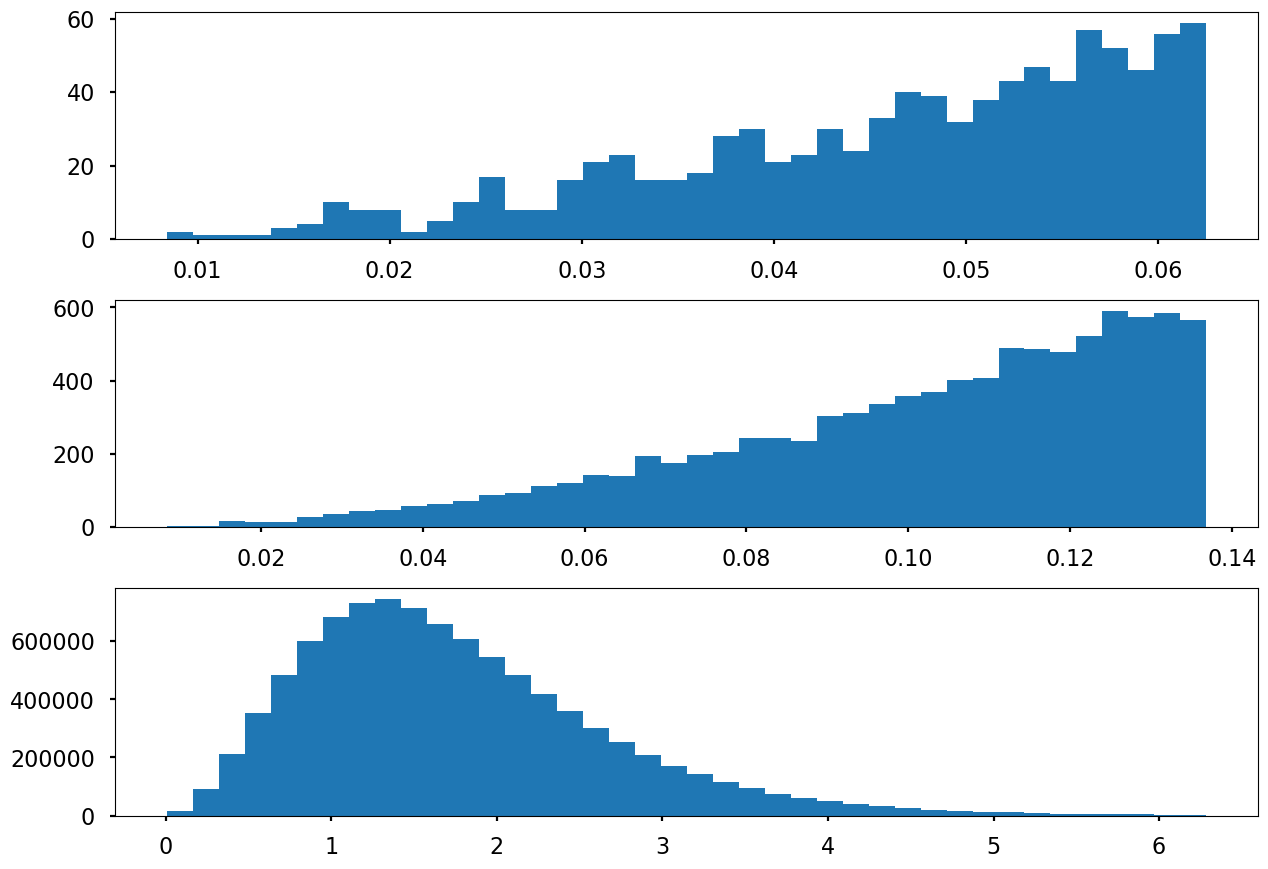

In [73]:
fig, ax = plt.subplots(3, 1, sharey=False, tight_layout=True)

ax[0].hist(tmp[tmp < np.quantile(tmp, 0.0001)], bins=40)
ax[1].hist(tmp[tmp < np.quantile(tmp, 0.001)], bins=40)
ax[2].hist(tmp[tmp < np.quantile(tmp, 0.999)], bins=40)

plt.show()

In [11]:
# PASTIS transfer function ONLY

alpha = -4

sc_counts = sc_dis_intramol.pow(alpha)
sc_counts_series = pd.Series(sc_counts.values.ravel())

counts = sc_counts.mean(axis=1)

print("Single-cell distances:\n" + pd.Series(sc_dis_intramol.values.ravel()).describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\nSingle-cell counts:\n" + sc_counts_series.describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\nConsensus counts:\n" + counts.describe().to_string(float_format=lambda x: f"{x:.2g}"))

Single-cell distances:
count   9.4e+06
mean        1.8
std        0.93
min      0.0084
25%         1.1
50%         1.6
75%         2.2
max          11

Single-cell counts:
count   9.4e+06
mean    1.5e+02
std     9.1e+04
min       6e-05
25%       0.039
50%        0.16
75%        0.72
max       2e+08

Consensus counts:
count   4.5e+04
mean    1.4e+02
std     5.3e+03
min       0.058
25%         1.7
50%         4.3
75%          13
max       7e+05


In [ ]:
# sns.histplot(data=pd.Series(counts.values.ravel()).to_frame(), x=r"Pseudo-counts, $\alpha = " + f"{alpha}" + "$")
# sns.histplot(data=counts, x=r"Pseudo-counts, $\alpha = " + f"{alpha}" + "$")
sns.histplot(data=counts.values)
plt.x_axis(r"Pseudo-counts, $\alpha = " + f"{alpha}" + "$")
plt.show()

In [9]:
# PASTIS transfer function + 0.75um cutoff
alpha = -4

sc_counts = sc_dis_intramol.pow(alpha)
sc_counts[sc_dis_intramol.notnull() & (sc_dis_intramol > 0.75)] = 0
# sc_counts_series = pd.Series(sc_counts.values.ravel())

counts = sc_counts.mean(axis=1)

print("Single-cell counts:\n" + pd.Series(sc_counts.values.ravel()).describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\nConsensus counts:\n" + counts.describe().to_string(float_format=lambda x: f"{x:.2g}"))

sc_counts_series = None
counts.isnull().sum(), (counts == 0).sum()

Single-cell counts:
count   9.4e+06
mean    1.5e+02
std     9.1e+04
min           0
25%           0
50%           0
75%           0
max       2e+08

Consensus counts:
count   4.5e+04
mean    1.4e+02
std     5.3e+03
min           0
25%         1.4
50%           4
75%          13
max       7e+05


In [12]:
# 0.75um cutoff only

sc_counts = pd.DataFrame(0, index=sc_dis_intramol.index, columns=sc_dis_intramol.columns)
sc_counts[sc_dis_intramol.notnull() & (sc_dis_intramol <= 0.75)] = 1
# sc_counts_series = pd.Series(sc_counts.values.ravel())

counts = sc_counts.mean(axis=1)

print("Single-cell counts:\n" + pd.Series(sc_counts.values.ravel()).describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\nConsensus counts:\n" + counts.describe().to_string(float_format=lambda x: f"{x:.2g}"))

sc_counts_series = None
counts.isnull().sum(), (counts == 0).sum()

Single-cell counts:
count   1.7e+08
mean     0.0061
std       0.078
min           0
25%           0
50%           0
75%           0
max           1

Consensus counts:
count   4.5e+04
mean     0.0061
std       0.005
min           0
25%      0.0027
50%      0.0049
75%      0.0078
max       0.052


(np.int64(0), np.int64(103))

### Dist decay - pseudo-counts

In [ ]:
# XXX shouldn't the distance decay be for ambiguated counts? not that it'll make a huge difference...

#### c ~ d^alpha

v = 0.785
1/v = 1.27
est alpha = B/v = -1.02


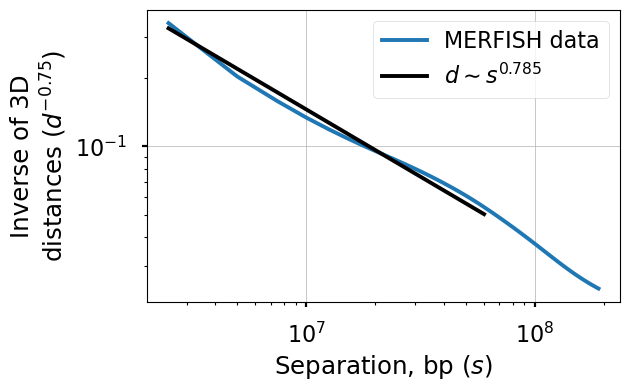

In [151]:
sigma_log10 = 0.1; min_n = None
# dis_exp = -4; min_distance = 0.1; max_distance = 0.75 # 0.162
# dis_exp = -4; min_distance = 0.1; max_distance = 1 # 0.161
# dis_exp = -4; min_distance = 0.1; max_distance = 0.5 # 0.164
# dis_exp = -4; min_distance = 0.01; max_distance = 0.5 # 0.151, noisy
# dis_exp = -4; min_distance = 0.05; max_distance = 0.5 # 0.167
# dis_exp = -4; min_distance = 0.025; max_distance = 0.5 # 0.177
# dis_exp = -3; min_distance = 0.025; max_distance = 0.5 # 0.223
# dis_exp = -3; min_distance = 0.025; max_distance = 0.2 # 0.231
# dis_exp = -2; min_distance = 0.025; max_distance = 0.5 # 0.312
# dis_exp = -2; min_distance = 0.025; max_distance = 0.2 # 0.339 ++
# dis_exp = -2; min_distance = 0.025; max_distance = 0.1 # 0.346, noisier than max_dist=0.2
# dis_exp = -2; min_distance = 0.015; max_distance = 0.2 # 0.335
# dis_exp = -2; min_distance = 0.05; max_distance = 0.2 # 0.335
# dis_exp = -2; min_distance = 0.02; max_distance = 0.2 # 0.337

# dis_exp = -1; min_distance = 0.025; max_distance = 0.5 # 0.593
# dis_exp = -1; min_distance = 0.025; max_distance = 0.2 # 0.666 ++
# dis_exp = -0.75; min_distance = 0.025; max_distance = 0.2 # 0.886 ++
# dis_exp = -0.75; min_distance = 0.025; max_distance = None # 0.201 ++
dis_exp = -0.75; min_distance = None; max_distance = 0.2 # 0.886 ++
# dis_exp = -0.75; min_distance = None; max_distance = 0.5 # 0.785 ++
# dis_exp = -0.5; min_distance = 0.025; max_distance = 0.5 # 1.17
# dis_exp = -0.2; min_distance = 0.025; max_distance = 0.5 # 2.89
# dis_exp = -1; min_distance = None; max_distance = None  # 0.204 ++
# dis_exp = -0.2; min_distance = None; max_distance = None  # 0.196 ++
# dis_exp = -0.75; min_distance = None; max_distance = None  # 0.201 ++
# dis_exp = -1.5; min_distance = None; max_distance = None  # 0.209 ++
# dis_exp = -2; min_distance = None; max_distance = None  # 0.214 ++
# dis_exp = -2.5; min_distance = None; max_distance = None  # 0.214 ++
# dis_exp = -3; min_distance = None; max_distance = None  # 0.201 ++


counts_sc = sc_dis_intramol.pow(dis_exp)
if min_distance is not None:
    counts_sc[sc_dis_intramol.notnull() & (sc_dis_intramol < min_distance)] = np.power(min_distance, dis_exp)
if max_distance is not None:
    counts_sc[sc_dis_intramol.notnull() & (sc_dis_intramol > max_distance)] = 0
counts = counts_sc.mean(axis=1).to_frame().rename({0: 'sc_mean'}, axis=1)
counts_sc = None
counts_by_s = get_genomic_dist_by_cell(counts, dis_exp=1, min_n=min_n)

counts_by_s_smooth = smooth_frequency(counts_by_s, sigma_log10=sigma_log10)
d, (x, y), est_alpha = estimate_exponent_manual(counts_by_s_smooth, seed=0, dis_exp=dis_exp, verbose=True)

#### c = std logistic of x=-ln(d)

v = 0.661
1/v = 1.51
est alpha = B/v = -1.21


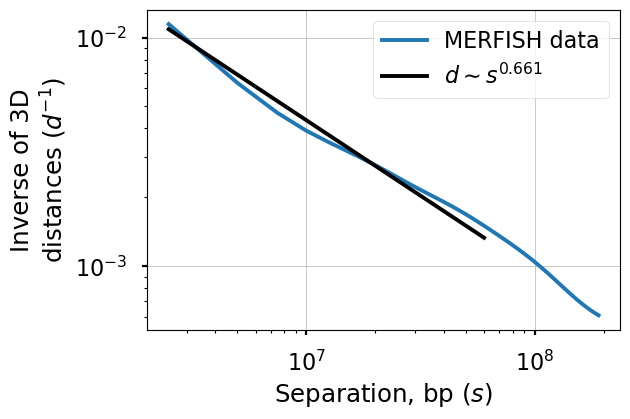

In [65]:
sigma_log10 = 0.1; min_n = None
# dis_exp = -4; min_distance = None; max_distance = None # 0.0853
# dis_exp = -4; min_distance = 0.01; max_distance = 0.75 # noise
# dis_exp = -3; min_distance = None; max_distance = None # 0.0913
# dis_exp = -2; min_distance = None; max_distance = None # 0.0974
# dis_exp = -1; min_distance = None; max_distance = None # 0.103
# dis_exp = -0.5; min_distance = None; max_distance = None # 0.106
# dis_exp = -0.25; min_distance = None; max_distance = None # 0.107

# dis_exp = -4; min_distance = None; max_distance = 0.75 # 0.131
# dis_exp = -4; min_distance = None; max_distance = 0.5 # 0.148
# dis_exp = -4; min_distance = None; max_distance = 0.2 # 0.166
# dis_exp = -3; min_distance = None; max_distance = 0.2 # 0.221
# dis_exp = -1; min_distance = None; max_distance = 0.75 # 0.494
# dis_exp = -1; min_distance = None; max_distance = 0.5 # 0.579
dis_exp = -1; min_distance = None; max_distance = 0.2 # 0.661

counts_sc = (1 + sc_dis_intramol).pow(dis_exp)  # power law where x=d+1 OR logistic fxn of x where x = -ln(d)
# alternative (1 + e^(10*(d-0.5)))^-1) = based on logistic fxn of x where x = -d (equiv to "1 - [logistic fxn of d]")
if min_distance is not None:
    counts_sc[sc_dis_intramol.notnull() & (sc_dis_intramol < min_distance)] = np.power(min_distance, dis_exp)
if max_distance is not None:
    counts_sc[sc_dis_intramol.notnull() & (sc_dis_intramol > max_distance)] = 0
counts = counts_sc.mean(axis=1).to_frame().rename({0: 'sc_mean'}, axis=1)
counts_sc = None
counts_by_s = get_genomic_dist_by_cell(counts, dis_exp=1, min_n=min_n)

counts_by_s_smooth = smooth_frequency(counts_by_s, sigma_log10=sigma_log10)
d, (x, y), est_alpha = estimate_exponent_manual(counts_by_s_smooth, seed=0, dis_exp=dis_exp, verbose=True)

#### c = logistic of x=

v = 0.681
1/v = 1.47
est alpha = B/v = -1.18


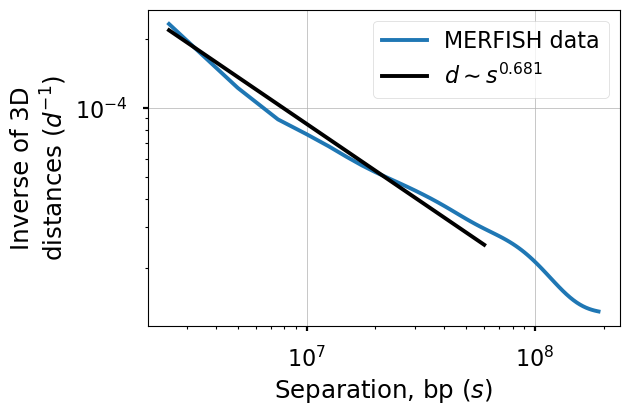

In [140]:
sigma_log10 = 0.1; min_n = None
L = 1
# k = -3;   x0=-0.5  # 0.412
# k = -10;   x0=-0.2  # 0.61
# k = -10;   x0=-0.1  # 0.608
# k = -15;   x0=-0.1  # 0.643
# k = -15;   x0=0     # 0.641
# k = -20;   x0=0     # 0.659
# k = -30;   x0=0     # 0.659
# k = -35;   x0=0     # 0.68
# k = -37;   x0=0     # 0.69
# k = -38;   x0=0     # 0.683
k = -39;   x0=+0.01     # 0.681
# k = -10;   x0=-0.5  # ??



def logistic(x, x0, k, L=1, v=1):
    # x0 <= 0 and k<0
    tmp = -k * (x - x0)
    # try1 = L / np.power(1 + np.exp(-k * (x - x0)), 1 / v)
    try2 = np.exp(np.log(L) - np.log1p(np.exp(tmp))) / v
    return try2



counts_sc = logistic(sc_dis_intramol, x0=x0, k=k, L=L)
counts = counts_sc.mean(axis=1).to_frame().rename({0: 'sc_mean'}, axis=1)
counts_sc = None
counts_by_s = get_genomic_dist_by_cell(counts, dis_exp=1, min_n=min_n)

counts_by_s_smooth = smooth_frequency(counts_by_s, sigma_log10=sigma_log10)
d, (x, y), est_alpha = estimate_exponent_manual(counts_by_s_smooth, seed=0, dis_exp=dis_exp, verbose=True)

In [10]:
def logistic_fun(x, x0, k, L=1):
    # x0 <= 0 and k<0
    tmp = -k * (x - x0)
    # try1 = L / (1 + np.exp(-k * (x - x0)))
    try2 = np.exp(np.log(L) - np.log1p(np.exp(tmp)))
    return try2

counts_sc = logistic_fun(sc_dis_intramol, x0=0, k=-10, L=1)

counts_sc.index = [j - i for i, j in counts_sc.index]

counts_sc = None

In [ ]:
counts_sc.groupby(level=0).var().mean(axis=1)

In [135]:
x = 10

correct = L / (1 + np.exp(x))
testing = np.exp(np.log(L) - np.log1p(np.exp(x)))
print(f"{correct=:.10}\n{testing=:.10g}")


# correct = 1 + np.exp(x)
# testing = np.exp(np.log1p(np.exp(x)))
# print(f"{correct=:.10}\n{testing=:.10g}")

correct=4.53978687e-05
testing=4.53978687e-05


## Analyze

In [ ]:
min_n = None
# dis_exp = -1; sigma_log10 = 0.01  # 1/exp = 4.9;   1/exp * dis_exp = 4.9;
# dis_exp = -3; sigma_log10 = 0.2   # 1/exp = ~2;    1/exp * dis_exp = 6;
# dis_exp = -0.5; sigma_log10 = 0.1   # 1/exp = 10;  1/exp * dis_exp = 5;
# dis_exp = -5; sigma_log10 = 0.1   # 1/exp =  2;    1/exp * dis_exp =  10;
# dis_exp = 1; sigma_log10 = 0.1  # 1/exp = 5.38;                        
dis_exp = -1; sigma_log10 = 0.1  # 1/exp = 4.9;   1/exp * dis_exp = 4.9
# dis_exp = -1; sigma_log10 = 0.1; min_n = 5; # similar to without min_n

s_by_cell = get_genomic_dist_by_cell(sc_dis_intramol, dis_exp=dis_exp, min_n=min_n)
s_by_cell_smooth = smooth_frequency(s_by_cell, sigma_log10=sigma_log10)
display(s_by_cell_smooth.head(3))
display(s_by_cell_smooth.tail(3))
# s_by_cell_smooth.n[s_by_cell_smooth.n != 0].describe()



======= MEAN =======

v = 0.195
1/v = 5.14
est alpha = B/v = -4.11


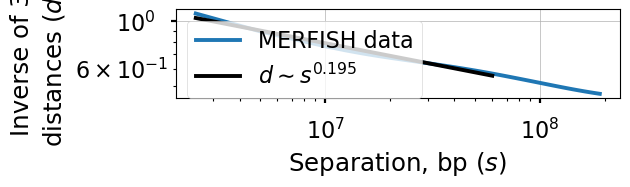



======= MEDIAN =======

v = 0.195
1/v = 5.14
est alpha = B/v = -4.11


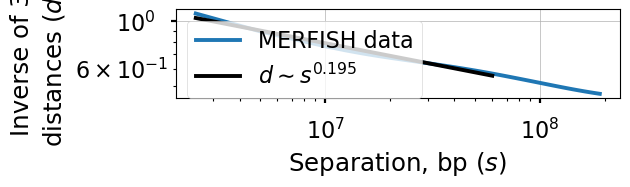

In [25]:
min_n = None
dis_exp = -1; sigma_log10 = 0.1

for agg in ('mean', 'median'):
    print(f"\n\n======= {agg.upper()} =======\n")
    sc_dis_intramol_mean = sc_dis_intramol.median(axis=1).to_frame().rename({0: f'sc_{agg}'}, axis=1)
    s_agg = get_genomic_dist_by_cell(sc_dis_intramol_mean, dis_exp=dis_exp, min_n=min_n)
    s_agg_smooth = smooth_frequency(s_agg, sigma_log10=sigma_log10)
    d, (x, y), est_alpha = estimate_exponent_manual(s_agg_smooth, seed=0, dis_exp=dis_exp, verbose=True)

v = -1.23
1/v = -0.816
est alpha = B/v = 0.653


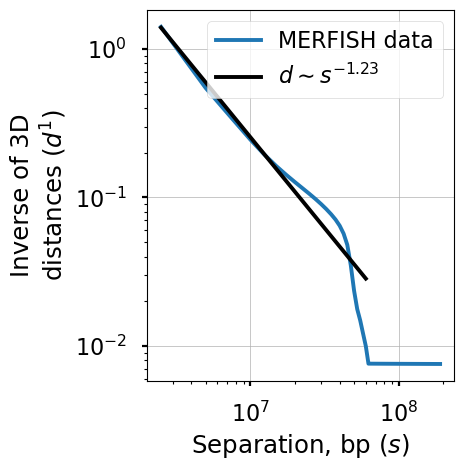

In [28]:
min_n = None
dis_exp = 1; sigma_log10 = 0.1

agg = 'median'  # for agg in ('mean', 'median'):
# print(f"\n\n======= {agg.upper()} =======\n")
sc_dis_intramol_mean = sc_dis_intramol.median(axis=1).to_frame().rename({0: f'sc_{agg}'}, axis=1)
s_agg = get_genomic_dist_by_cell(sc_dis_intramol_mean, dis_exp=dis_exp, min_n=min_n) ** -5
s_agg_smooth = smooth_frequency(s_agg, sigma_log10=sigma_log10)
d, (x, y), est_alpha = estimate_exponent_manual(s_agg_smooth, seed=0, dis_exp=dis_exp, verbose=True)

### Get exponent per cell

In [336]:
def get_exponent_per_cell(df, dis_exp):
    genomic_dis = df.index.values
    freq_smooth = df.smoothed_freq.values.ravel()
    
    d = estimate_exponent(genomic_dis, freq_smooth=freq_smooth, verbose=False)
    # d = estimate_exponent(
    #     genomic_dis, freq_smooth=freq_smooth, x0=x0, bounds=bounds, seed=seed,
    #     max_iter=max_iter, verbose=False)

    v = d['exponent'] / dis_exp
    detected_genomic_dis = s = df[df.n > 0].index.values
    res = {
        'v': v, 'n_sum': df.n.sum(), 'detected_sum': df.n.notnull().sum(),
        's_size': int(s.size), 's_mean': s.mean(), 's_median': np.median(s),
        's_range': int(s.max() - s.min() + 1)}
    return pd.Series(res)


min_genomic_dis = None; max_genomic_dis = 'default'

if min_genomic_dis is None:
    min_genomic_dis = s_by_cell_smooth.index.min()
if max_genomic_dis is None:
    max_genomic_dis = s_by_cell_smooth.index.max()
elif isinstance(max_genomic_dis, str) and max_genomic_dis.lower() == 'default':
    max_genomic_dis = 6e7
mask = (s_by_cell_smooth.index <= max_genomic_dis) & (s_by_cell_smooth.index >= min_genomic_dis)

# tmp = s_by_cell_smooth[mask].groupby('cell_num').apply(get_exponent_per_cell, dis_exp=dis_exp, include_groups=False)
# n_sum = s_by_cell_smooth[mask].groupby('cell_num').n.sum().to_frame().rename({'n': 'n_sum'}, axis=1)
# per_cell = pd.concat([n_sum, tmp.to_frame().rename({0: 'v'}, axis=1)], axis=1)

per_cell = s_by_cell_smooth[mask].groupby('cell_num').apply(get_exponent_per_cell, dis_exp=dis_exp, include_groups=False)
for col in [col in per_cell.columns if col != 'v']:  #['n_sum', 's_size', 's_mean', 's_median', 's_range']:
    per_cell[col] = per_cell[col].astype(int)

In [372]:
min_nsum = int(round(per_cell.n_sum.quantile(0.5)))

display(per_cell.describe().round(2))
print('\ns < -0.25')
display(per_cell[per_cell.v < -0.25].describe().round(2))
print(f'\nn_sum > {min_nsum}')
display(per_cell[per_cell.n_sum >= min_nsum].describe().round(2))

pairs_per_cell = s_by_cell_smooth[mask].groupby('cell_num').n.sum()
cells_to_use = pairs_per_cell[pairs_per_cell >= min_nsum].index
num_pairs_orig = sc_dis_intramol.notnull().values.sum()
num_pairs_final = sc_dis_intramol[cells_to_use].notnull().values.sum()
print(f"Retaining {round(num_pairs_final / num_pairs_orig * 100):g}% of pairs")

,v,n_sum,s_size,s_mean,s_median,s_range
count,3702.00,3702.00,3702.00,3702.00,3702.00,3702.00
mean,0.15,2536.00,59.65,30.07,30.07,60.44
std,0.34,2584.42,12.52,6.25,6.25,12.44
min,-2.74,28.00,15.00,9.00,9.00,17.00
25%,0.15,630.00,50.00,25.00,25.00,50.00
50%,0.19,1550.00,60.00,30.00,30.00,61.00
75%,0.23,3629.00,71.00,36.00,36.00,71.00
max,0.66,14663.00,76.00,38.00,38.00,76.00



s < -0.25


,v,n_sum,s_size,s_mean,s_median,s_range
count,53.00,53.00,53.00,53.00,53.00,53.00
mean,-2.44,106.66,23.25,12.08,12.19,24.25
std,0.77,108.89,7.71,3.83,3.85,7.69
min,-2.74,28.00,15.00,9.00,9.00,17.00
25%,-2.74,55.00,20.00,10.00,10.00,21.00
50%,-2.74,78.00,21.00,11.00,11.00,22.00
75%,-2.74,105.00,23.00,12.00,12.00,23.00
max,-0.26,631.00,55.00,28.00,28.00,57.00



n_sum > 1550


,v,n_sum,s_size,s_mean,s_median,s_range
count,1852.00,1852.00,1852.00,1852.00,1852.00,1852.00
mean,0.20,4375.34,67.95,34.22,34.22,68.58
std,0.05,2533.50,7.05,3.52,3.52,7.09
min,-0.08,1550.00,47.00,24.00,24.00,47.00
25%,0.17,2355.00,61.00,31.00,31.00,61.00
50%,0.20,3629.00,70.00,35.00,35.00,71.00
75%,0.23,5704.25,75.00,38.00,38.00,75.00
max,0.40,14663.00,76.00,38.00,38.00,76.00


Retaining 86% of pairs


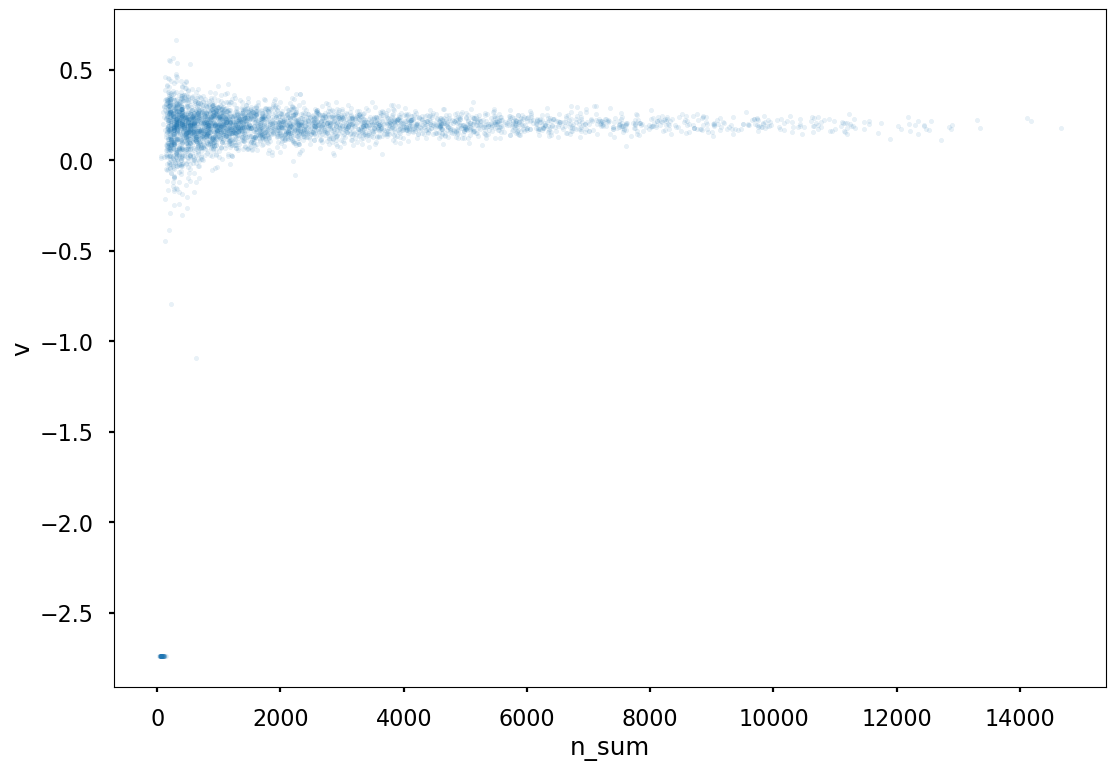

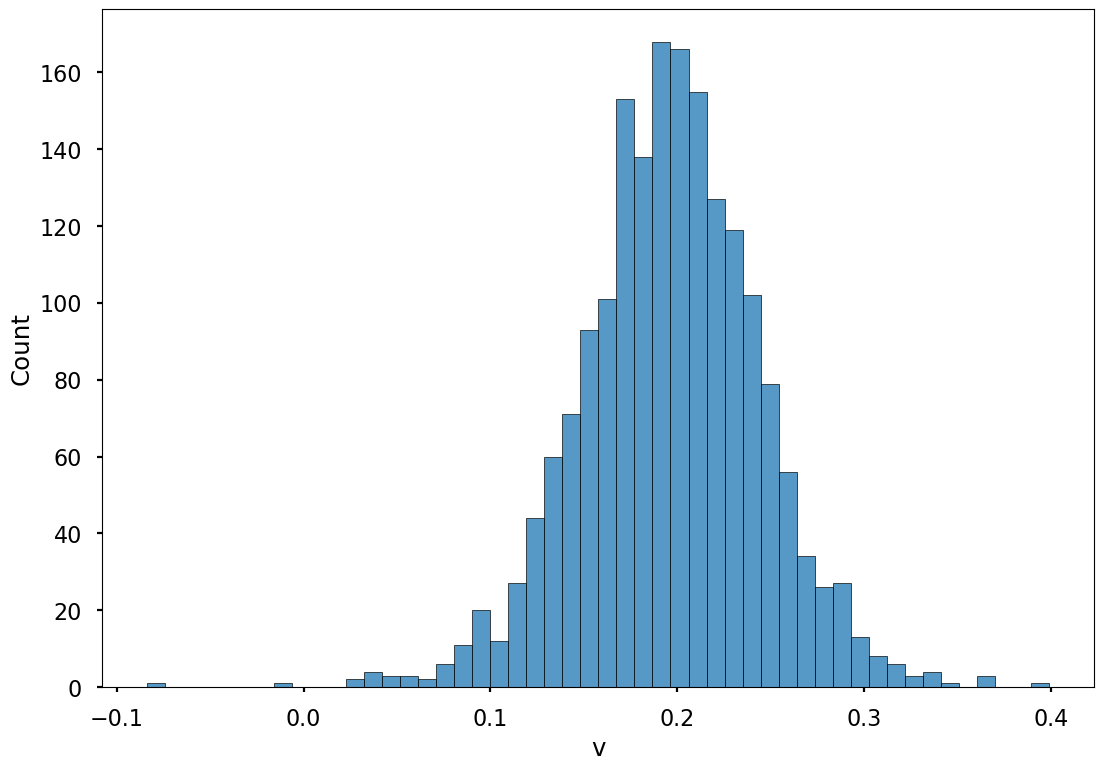

In [367]:
sns.scatterplot(data=per_cell, x="n_sum", y="v", s=10, alpha=0.1, edgecolors=None)  # 
plt.show()

sns.histplot(data=per_cell[per_cell.n_sum > per_cell.n_sum.quantile(0.5)], x="v")
plt.show()

## Plot

v = 0.143
1/v = 7.02
est alpha = B/v = -5.61


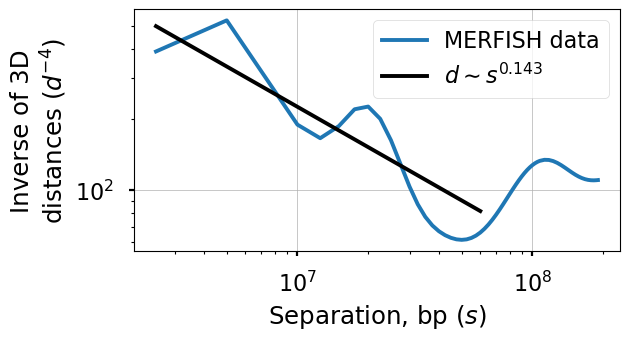

v = 0.143
1/v = 7.02
est alpha = B/v = -5.61


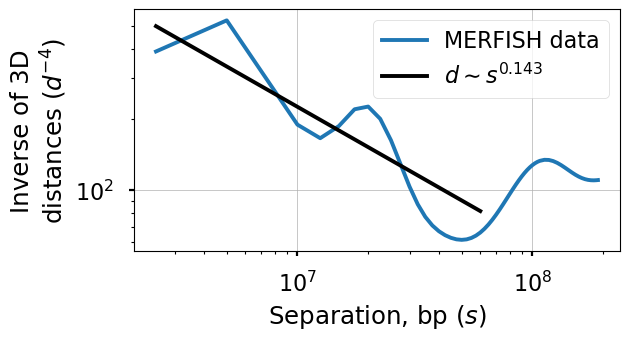

In [93]:
min_nsum = 0


data_smooth = s_smooth
data_orig = s_by_cell
if min_nsum > 1:
    pairs_per_cell = s_smooth[s_smooth.n >= min_nsum].groupby('cell_num').n.sum()
    cells_to_use = pairs_per_cell[pairs_per_cell >= min_nsum].index
    num_pairs_orig = sc_dis_intramol.notnull().values.sum()
    num_pairs_final = sc_dis_intramol[cells_to_use].notnull().values.sum()
    print(f"Retaining {round(num_pairs_final / num_pairs_orig * 100):g}% of pairs\n\n")
    data_smooth = data_smooth[data_smooth.cell_num.isin(cells_to_use)]
    data_orig = data_orig[cells_to_use]
# data_smooth = data_smooth.copy(); data_smooth[data_smooth.n < 40] = np.nan

# s_smooth_mean = data_smooth.groupby(level=0).mean().drop('cell_num', axis=1)
# # display(s_smooth_mean.head(2)); display(s_smooth_mean.tail(2))
# d, (x, y), est_alpha = estimate_exponent_manual(s_smooth_mean, seed=0, dis_exp=dis_exp, verbose=True)

# s_smooth_med = data_smooth.groupby(level=0).median().drop('cell_num', axis=1)
# # display(s_smooth_med.head(2)); display(s_smooth_med.tail(2))
# d, (x, y), est_alpha = estimate_exponent_manual(s_smooth_med, seed=0, dis_exp=dis_exp, verbose=True)

s_by_cell_mean = data_orig.mean(axis=1).to_frame().rename({0: 'sc_mean'}, axis=1)
s_mean_smooth = smooth_frequency(s_by_cell_mean, sigma_log10=0.1)
# display(s_mean_smooth.head(2)); display(s_mean_smooth.tail(2))
d, (x, y), est_alpha = estimate_exponent_manual(s_mean_smooth, seed=0, dis_exp=dis_exp, verbose=True)


s_by_cell_med = data_orig.median(axis=1).to_frame().rename({0: 'sc_median'}, axis=1)
s_med_smooth = smooth_frequency(s_by_cell_mean, sigma_log10=0.1)
# display(s_med_smooth.head(2)); display(s_med_smooth.tail(2))
d, (x, y), est_alpha = estimate_exponent_manual(s_med_smooth, seed=0, dis_exp=dis_exp, verbose=True)

## Fxn

In [ ]:
%run fit_dist_decay.py

In [2]:
n = 11
x_true = np.triu(np.ones((n, n)), 1).sum()
x = (n ** 2 - n) / 2
n_result = int((1 + np.sqrt(1 + 8 * x)) / 2)
print(x_true, x)
print(n, n_result)

55.0 55.0
11 11
